## Visualização dos dados:

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 180)
sns.set_style("whitegrid")

def analyze_csv(path):
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"Arquivo não encontrado: {path}\n")
        return

    print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas\n")
    print("Primeiras linhas:")
    print(df.head(), "\n")

    if "radiant_win" in df.columns:
        counts = df["radiant_win"].value_counts()
        percentages = df["radiant_win"].value_counts(normalize=True) * 100

        print("Distribuição de resultados (radiant_win):")
        print(pd.DataFrame({
            "Contagem": counts,
            "Percentual (%)": percentages.round(2)
        }), "\n")

        # Preparar gráfico
        plt.figure(figsize=(6,4))
        ax = sns.barplot(
            x=counts.index.astype(str),
            y=counts.values,
            palette=["#1f77b4", "#ff7f0e"]
        )

        # Adicionar valores sobre as barras
        for i, (count, pct) in enumerate(zip(counts.values, percentages)):
            ax.text(i, count + 50, f"{count}\n({pct:.1f}%)",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.set_title("Distribuição de radiant_win", fontsize=14, fontweight='bold')
        ax.set_xlabel("Radiant Win", fontsize=12)
        ax.set_ylabel("Contagem", fontsize=12)
        plt.ylim(0, counts.max() * 1.2)
        plt.show()
    else:
        print("Coluna 'radiant_win' não encontrada.\n")


## Dados limpos + conversão ID's para nomes de heróis:

Dimensões: 9700 linhas x 5 colunas

Primeiras linhas:
   radiant_win    radiant_team_sorted        dire_team_sorted                                                                   radiant_heroes  \
0         True   [2, 17, 53, 86, 121]  [14, 47, 94, 105, 110]              ['Axe', 'Storm Spirit', "Nature's Prophet", 'Rubick', 'Grimstroke']   
1        False  [11, 12, 27, 56, 101]   [1, 30, 90, 104, 136]   ['Shadow Fiend', 'Phantom Lancer', 'Shadow Shaman', 'Clinkz', 'Skywrath Mage']   
2         True  [6, 11, 64, 101, 104]   [21, 26, 57, 93, 107]   ['Drow Ranger', 'Shadow Fiend', 'Jakiro', 'Skywrath Mage', 'Legion Commander']   
3         True  [38, 52, 72, 84, 123]   [20, 36, 40, 93, 128]                ['Beastmaster', 'Leshrac', 'Gyrocopter', 'Ogre Magi', 'Hoodwink']   
4        False   [23, 38, 39, 81, 96]    [11, 45, 49, 66, 71]  ['Kunkka', 'Beastmaster', 'Queen of Pain', 'Chaos Knight', 'Centaur Warrunner']   

                                                                     

C:\Users\izalo\AppData\Local\Temp\ipykernel_8128\657848584.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


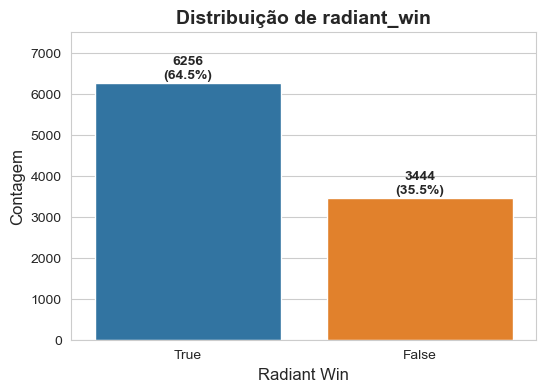

In [18]:
analyze_csv("../data/processed/matches_clean.csv")